Imports

In [ ]:
import mysql.connector
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes

from scipy import stats
from scipy.stats import chi2_contingency

In [3]:
data_dir = Path("../Data")
input_file = data_dir / "2026-07-06_bank_dataset_transformed.csv"

df = pd.read_csv(input_file, encoding="utf-8-sig")

print(f"Dataset loaded from: {input_file.resolve()}")
print(f"Shape: {df.shape}")

df.head(10)

Dataset loaded from: C:\Users\nowan\Documents\itacademy\Simulador\ProjecteData\Equip_32\Data\2026-07-06_bank_dataset_transformed.csv
Shape: (10975, 28)


,id,age,job,marital,education,default,balance,housing,loan,contact,...,no_previous_contact,had_previous_contact,age_group,financial_burden,financial_burden_label,education_rank,education_label,job_profile,week_of_month,campaign_group
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,...,1,0,Middle-Aged (51-65),1,Low burden,2.0,Secondary,White Collar,1,0-3
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,...,1,0,Middle-Aged (51-65),0,No burden,2.0,Secondary,White Collar,1,0-3
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,...,1,0,Adult (36-50),1,Low burden,2.0,Secondary,White Collar,1,0-3
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,...,1,0,Middle-Aged (51-65),1,Low burden,2.0,Secondary,Blue Collar,1,0-3
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,...,1,0,Middle-Aged (51-65),0,No burden,3.0,Tertiary,White Collar,1,0-3
5,6,42.0,management,single,tertiary,no,0,yes,yes,unknown,...,1,0,Adult (36-50),2,High burden,3.0,Tertiary,White Collar,1,0-3
6,7,56.0,management,married,tertiary,no,830,yes,yes,unknown,...,1,0,Middle-Aged (51-65),2,High burden,3.0,Tertiary,White Collar,1,0-3
7,8,60.0,retired,divorced,secondary,no,545,yes,no,unknown,...,1,0,Middle-Aged (51-65),1,Low burden,2.0,Secondary,Retired,1,0-3
8,9,37.0,technician,married,secondary,no,1,yes,no,unknown,...,1,0,Adult (36-50),1,Low burden,2.0,Secondary,White Collar,1,0-3
9,10,28.0,services,single,secondary,no,5090,yes,no,unknown,...,1,0,Young Adult (26-35),1,Low burden,2.0,Secondary,Blue Collar,1,0-3


### Business Question

Which demographic characteristics are associated with a higher probability of subscribing to a term deposit?

### Analytical approach

This analysis focuses on demographic variables only. First, each demographic characteristic is evaluated individually. Then, the variables are combined to identify customer segments with the highest subscription rates.

In [3]:
# Reusable function to analyze demographic variables consistently.
# The function generates both a summary table and a bar chart.

def analyze_profile_variable(df, variable, order=None, sort=False, reverse_palette=False):

# Compute subscription rates and sample size for each demographic category
   
    summary = (
        df.groupby(variable, observed=True)["deposit"]
          .value_counts(normalize=True)
          .unstack()
          .mul(100)
          .rename(columns={
              1: "subscription_rate",
              0: "non_subscription_rate"
          })
          .round(1)
    )

    summary["n_clients"] = (
        df.groupby(variable, observed=True)
          .size()
    )

# Display the categories in a clear order

    if order is not None:
        summary = summary.reindex(order)
    elif sort:
        summary = summary.sort_values(
            by="subscription_rate",
            ascending=False
        )

    display(summary)

# Add sample size to x-axis labels

    summary["label"] = [
        f"{category}\nn={n:,}"
        for category, n in zip(summary.index, summary["n_clients"])
    ]

# Create a consistent colour palette for all demographic charts

    if reverse_palette:
        colors = ["#DDEFE6", "#8DB79A", "#4F8A6A", "#1F5C45"]
    else:
        colors = ["#1F5C45", "#4F8A6A", "#8DB79A", "#DDEFE6"]

    palette = sns.blend_palette(
        colors,
        n_colors=summary.shape[0]
    )

    plot_data = summary.reset_index()

    plt.figure(figsize=(10,5))

    # Visualize subscription rates across demographic categories

    sns.barplot(
    data=plot_data,
    x="label",
    y="subscription_rate",
    hue="label",
    order=summary["label"],
    hue_order=summary["label"],
    palette=palette,
    legend=False,
    width=0.8,
    dodge=False)

    # Add subscription rates inside the bars
    
    for index, row in plot_data.iterrows():
        plt.text(
            x=index,
            y=row["subscription_rate"] / 2,
            s=f'{row["subscription_rate"]:.1f}%',
            ha="center",
            va="center",
            fontsize=10,
            color="#1F2D26",
            fontweight="normal"
        )

    plt.title(f"Deposit Subscription Rate by {variable.replace('_',' ').title()}")
    plt.xlabel(variable.replace("_"," ").title())
    plt.ylabel("Subscription Rate (%)")
    plt.xticks(rotation=30, ha="right")

    plt.tight_layout()
    plt.show()

### Age

Age is analysed first to determine whether subscription behaviour changes across different stages of life.

deposit,non_subscription_rate,subscription_rate,n_clients
age_group,,,
Senior (65+),18.6,81.4,392
Young (18-25),27.0,73.0,437
Middle-Aged (51-65),49.6,50.4,1969
Young Adult (26-35),50.0,50.0,3735
Adult (36-50),56.4,43.6,4097


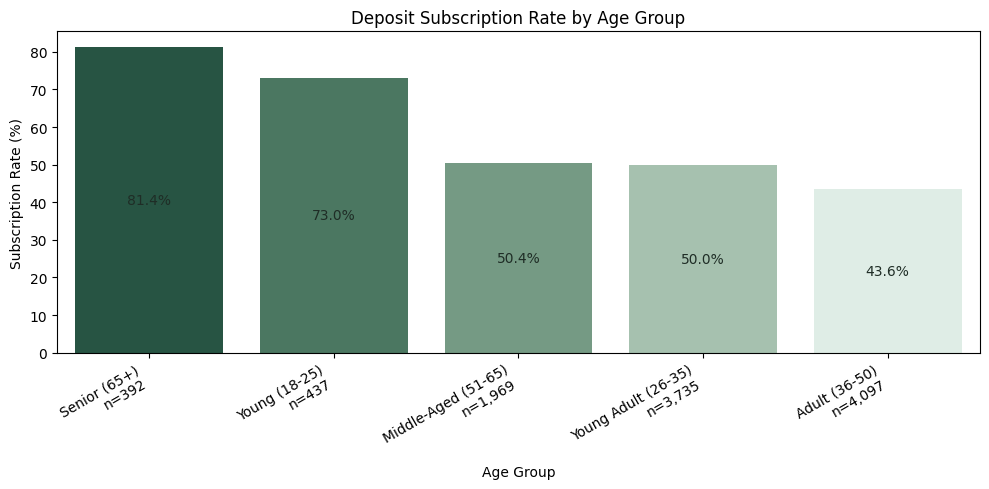

In [4]:
age_order = [
    "Young (18-25)",
    "Young Adult (26-35)",
    "Adult (36-50)",
    "Middle-Aged (51-65)",
    "Senior (65+)"
]

analyze_profile_variable(df, "age_group", sort=True)

Customers aged 60 and over present the highest conversion rate (around 78%), suggesting that older clients are considerably more likely to subscribe to a term depo
sit than younger age groups. This may be related to greater financial stability or more conservative investment preferences, although further analysis would be required to confirm these factors.


### Job profile

Occupational groups are compared to identify whether employment status influences customers' propensity to subscribe.

deposit,non_subscription_rate,subscription_rate,n_clients
job_profile,,,
Student,24.1,75.9,353
Retired,31.7,68.3,754
Unemployed,40.2,59.8,338
White Collar,49.3,50.7,5456
Unknown,50.0,50.0,68
Self-Employed,55.4,44.6,695
Blue Collar,60.0,40.0,2966


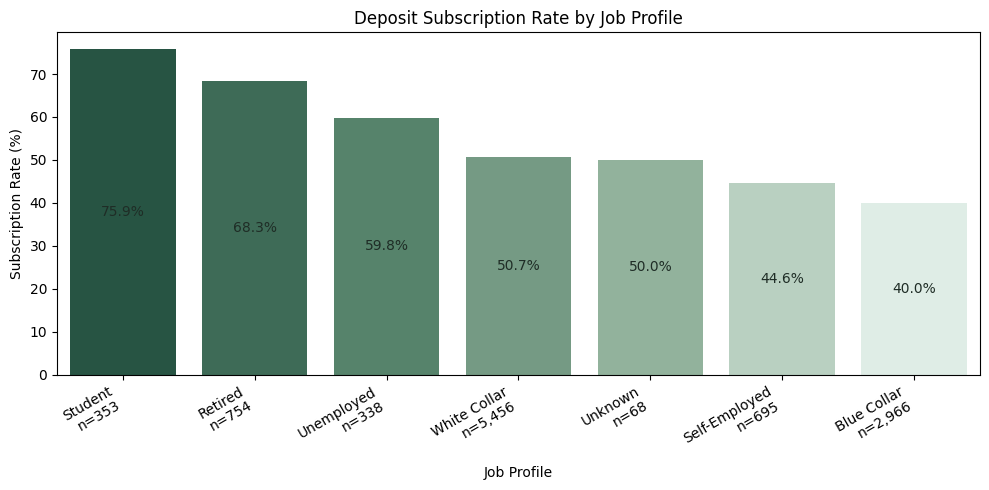

In [5]:
analyze_profile_variable(df, "job_profile", sort=True)

Students and retired customers exhibit the highest subscription rates, while operational occupations show the lowest conversion.
This suggests that employment profile is an important differentiating factor in customer behaviour.

In [6]:
pd.crosstab(
    df["job"],
    df["deposit"],
    normalize="index"
).mul(100).round(1)

deposit,0,1
job,,
admin.,50.6,49.4
blue-collar,61.3,38.7
entrepreneur,59.9,40.1
housemaid,57.6,42.4
management,46.9,53.1
retired,31.7,68.3
self-employed,51.8,48.2
services,58.1,41.9
student,24.1,75.9


### Education

Education level is evaluated as a potential indicator of financial behaviour and product adoption.

deposit,non_subscription_rate,subscription_rate,n_clients
education_label,,,
Tertiary,43.5,56.5,3526
Unknown,46.7,53.3,473
Secondary,53.1,46.9,5214
Primary,58.3,41.7,1417


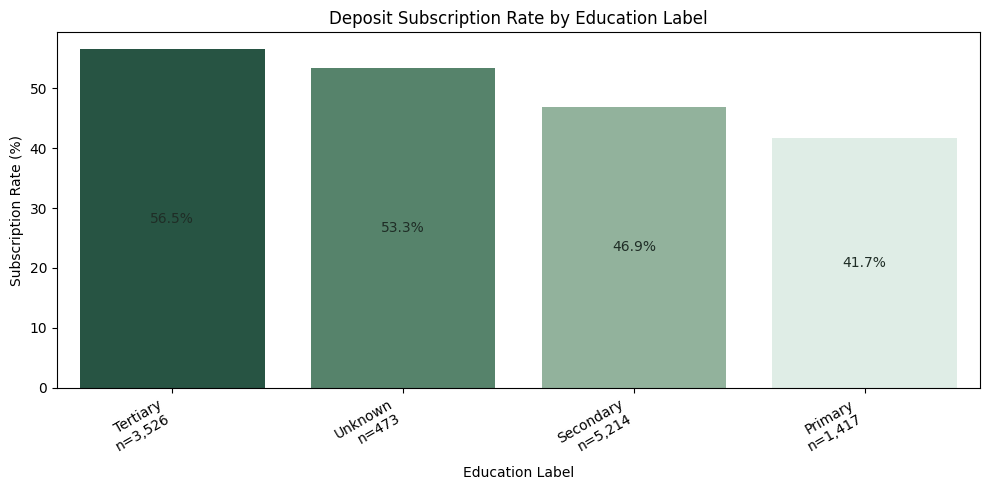

In [7]:
analyze_profile_variable(df, "education_label", sort=True)

Customers with tertiary education consistently achieve the highest subscription rates, whereas secondary education records the lowest conversion. The results suggest a positive association between education level and deposit subscription.

### Marital Status

Marital status is analysed to assess whether customers’ family situation is associated with different subscription rates.

deposit,non_subscription_rate,subscription_rate,n_clients
marital,,,
single,43.4,56.6,3370
divorced,49.7,50.3,1233
married,54.3,45.7,6027


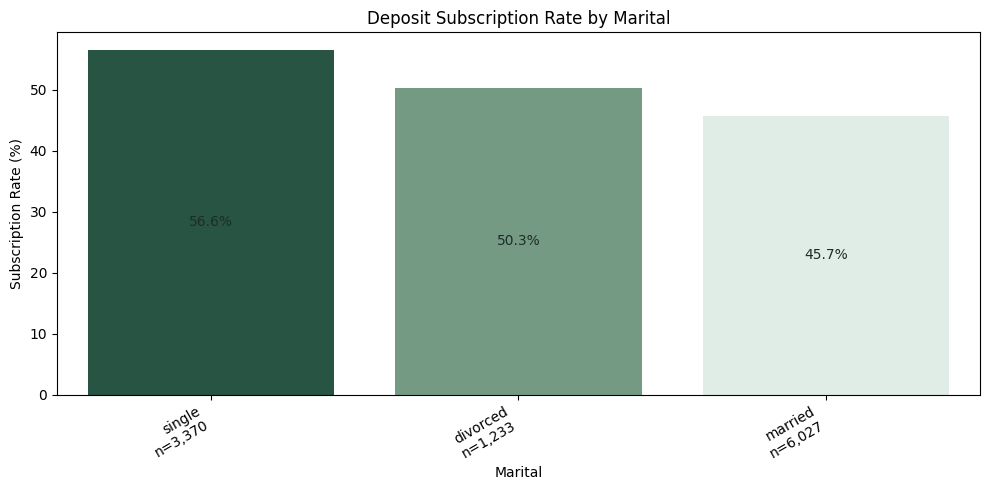

In [8]:
analyze_profile_variable(df, "marital", sort=True)

Single customers show the highest subscription rate, while married customers present the lowest conversion. This suggests that marital status may be associated with different financial priorities and product adoption behaviour.

### Age x Job

Combining demographic variables provides a more detailed customer profile than analysing each characteristic separately. The heatmap highlights the interaction between age and occupation.

In [9]:
summary = (
    df.groupby(["age_group", "job_profile"], observed=True)["deposit"]
      .value_counts(normalize=True)
      .unstack()
      .mul(100)
      .rename(columns={1: "subscription_rate",
                       0: "non_subscription_rate"})
      .round(1)
)

summary["n_clients"] = (
    df.groupby(["age_group", "job_profile"], observed=True)
      .size()
)

display(summary)

deposit                            non_subscription_rate  subscription_rate  \
age_group           job_profile                                               
Adult (36-50)       Blue Collar                     63.6               36.4   
                    Retired                         70.6               29.4   
                    Self-Employed                   60.9               39.1   
                    Student                         36.4               63.6   
                    Unemployed                      45.0               55.0   
                    Unknown                         58.1               41.9   
                    White Collar                    52.4               47.6   
Middle-Aged (51-65) Blue Collar                     61.0               39.0   
                    Retired                         41.5               58.5   
                    Self-Employed                   57.9               42.1   
                    Unemployed                      36.1               63.9   
                    Unknown                         40.0               60.0   
                    White Collar                    47.2               52.8   
Senior (65+)        Blue Collar                     21.4               78.6   
                    Retired                         18.8               81.2   
                    Self-Employed                    NaN              100.0   
                    Unknown                         50.0               50.0   
                    White Collar                    13.6               86.4   
Young (18-25)       Blue Collar                     32.4               67.6   
                    Self-Employed                   21.4               78.6   
                    Student                         18.8               81.2   
                    Unemployed                      16.7               83.3   
                    White Collar                    35.1               64.9   
Young Adult (26-35) Blue Collar                     58.3               41.7   
                    Retired                          NaN              100.0   
                    Self-Employed                   50.4               49.6   
                    Student                         28.7               71.3   
                    Unemployed                      37.8               62.2   
                    Unknown                         46.2               53.8   
                    White Collar                    48.1               51.9   

deposit                            n_clients  
age_group           job_profile               
Adult (36-50)       Blue Collar         1326  
                    Retired               17  
                    Self-Employed        304  
                    Student               22  
                    Unemployed           149  
                    Unknown               31  
                    White Collar        2248  
Middle-Aged (51-65) Blue Collar          474  
                    Retired              390  
                    Self-Employed        133  
                    Unemployed            72  
                    Unknown               20  
                    White Collar         880  
Senior (65+)        Blue Collar           14  
                    Retired              346  
                    Self-Employed          6  
                    Unknown                4  
                    White Collar          22  
Young (18-25)       Blue Collar          102  
                    Self-Employed         14  
                    Student              181  
                    Unemployed             6  
                    White Collar         134  
Young Adult (26-35) Blue Collar         1050  
                    Retired                1  
                    Self-Employed        238  
                    Student              150  
                    Unemployed           111  
                    Unknown               13  
              

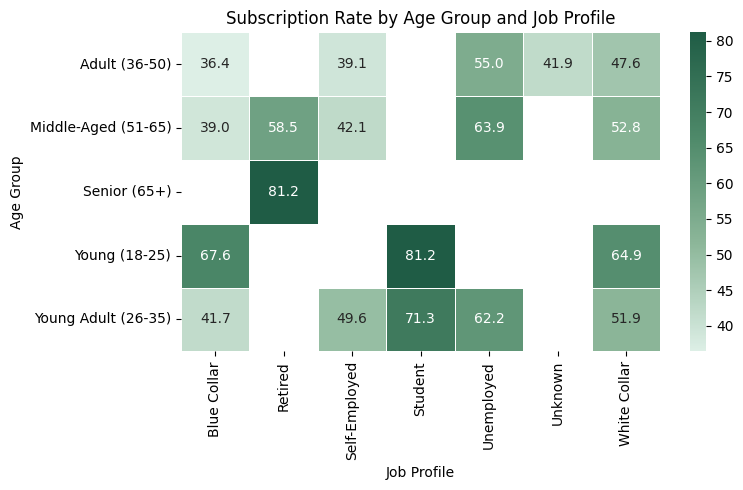

In [10]:
summary_filtered = summary.copy()
summary_filtered.loc[
    summary_filtered["n_clients"] < 30,
    "subscription_rate"
] = np.nan

heatmap_data = summary_filtered["subscription_rate"].unstack()
plt.figure(figsize=(8,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap=sns.blend_palette(
        ["#DDEFE6", "#8DB79A", "#4F8A6A", "#1F5C45"],
        as_cmap=True
    ),
    linewidths=0.5
)

plt.title("Subscription Rate by Age Group and Job Profile")
plt.xlabel("Job Profile")
plt.ylabel("Age Group")

plt.tight_layout()
plt.show()

Students and retired customers consistently present the highest subscription rates, whereas operational occupations remain the weakest-performing group across most age segments. Results from very small groups should be interpreted cautiously. Cells with missing values represent combinations with insufficient observations and were excluded from interpretation.

### Education × Marital

A second multivariate analysis explores whether education and marital status jointly influence subscription behaviour.

In [11]:
summary = (
    df.groupby(["education_label", "marital"], observed=True)["deposit"]
      .value_counts(normalize=True)
      .unstack()
      .mul(100)
      .rename(columns={
          1: "subscription_rate",
          0: "non_subscription_rate"
      })
      .round(1)
)

summary["n_clients"] = (
    df.groupby(["education_label", "marital"], observed=True)
      .size()
)

display(summary)

deposit                   non_subscription_rate  subscription_rate  n_clients
education_label marital                                                      
Primary         divorced                   47.5               52.5        198
                married                    61.7               38.3       1035
                single                     50.5               49.5        184
Secondary       divorced                   53.5               46.5        621
                married                    56.0               44.0       2965
                single                     47.5               52.5       1628
Tertiary        divorced                   44.7               55.3        367
                married                    48.0               52.0       1754
                single                     37.5               62.5       1405
Unknown         divorced                   48.9               51.1         47
                married                    48.0               52.0        273
                single                     43.8               56.2        153

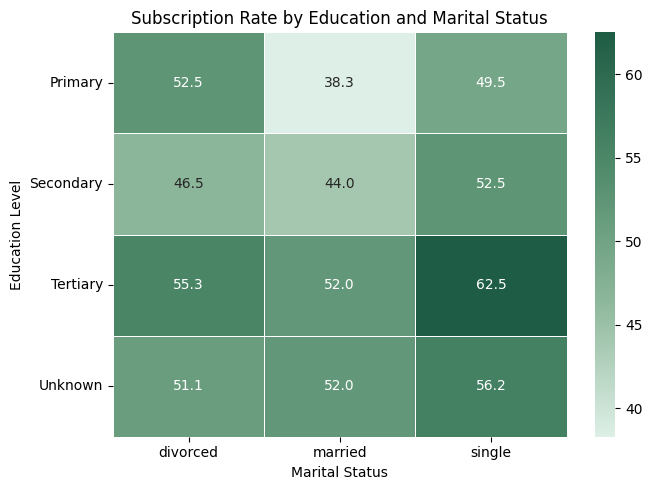

In [12]:
# filter small groups

summary_filtered = summary.copy()

summary_filtered.loc[
    summary_filtered["n_clients"] < 30,
    "subscription_rate"
] = np.nan

# heatmap

heatmap_data = summary_filtered["subscription_rate"].unstack()

# order

education_order = [
    "Primary",
    "Secondary",
    "Tertiary",
    "Unknown"
]

heatmap_data = heatmap_data.reindex(education_order)

plt.figure(figsize=(7,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap=sns.blend_palette(
        ["#DDEFE6", "#8DB79A", "#4F8A6A", "#1F5C45"],
        as_cmap=True
    ),
    linewidths=0.5
)

plt.title("Subscription Rate by Education and Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Education Level")

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Subscription rates tend to increase with higher education levels, especially among single customers. Married customers with primary or secondary education show the lowest conversion rates, while single customers with tertiary education exhibit the highest subscription rate (62.5%).

## Business Conclusions

### Key findings

Older customers, students and retired clients exhibit the highest subscription rates.
Tertiary education is consistently associated with higher conversion.
Multivariate analysis confirms that demographic characteristics interact, producing customer segments with substantially different subscription behaviour.

The analysis indicates that the most favourable customer profile combines higher education, single marital status, and demographic segments such as students or retirees, which consistently achieve the highest subscription rates across the analyses.

### Business implication

Demographic profiling can support more targeted marketing campaigns by identifying customer segments with the highest likelihood of subscribing to a term deposit.

# Clusteritzacions

## Clusteritació amb k-prototiper directa

In [ ]:

# # 2. Seleccionar només variables d'identitat (sense financial_burden, balance, ni duration/campaign/pdays/previous/poutcome)
# cluster_vars = ['age', 'job_profile', 'education_label', 'marital']
# df_cluster = df[cluster_vars].copy()

# # 3. Escalar age (obligatori per K-Prototypes)
# scaler = StandardScaler()
# df_cluster['age_scaled'] = scaler.fit_transform(df_cluster[['age']])

# # 4. Preparar la matriu: numèrica primer, categòriques després
# X = df_cluster[['age_scaled', 'job_profile', 'education_label', 'marital']].values
# categorical_idx = [1, 2, 3]  # posicions de les columnes categòriques dins de X

# # 5. Elbow method (k=2 a 7)
# costs = []
# for k in range(2, 8):
#     kproto = KPrototypes(n_clusters=k, init='Cao', n_init=3, random_state=42)
#     kproto.fit_predict(X, categorical=categorical_idx)
#     costs.append(kproto.cost_)
#     print(f"k={k} -> cost={kproto.cost_:.1f}")

# # 6. Entrenar model final amb k=4 (a confirmar segons la vostra lectura del colze)
# kproto_final = KPrototypes(n_clusters=4, init='Cao', n_init=5, random_state=42)
# df['cluster'] = kproto_final.fit_predict(X, categorical=categorical_idx)


## Clusteritació amb k-prototiper directa + segments students/retired

In [ ]:
# 2. Separar els segments de regla de negoci
df_rest = df[~df['job_profile'].isin(['Student', 'Retired'])].copy()

print(f"Total dataset: {len(df)}")
print(f"Excloent Student i Retired: {len(df_rest)}")
print(df['job_profile'].value_counts())

In [ ]:
# 3. Seleccionar variables d'identitat (sense financial_burden, balance, ni variables de campanya)
cluster_vars = ['age', 'job_profile', 'education_label', 'marital']
df_cluster = df_rest[cluster_vars].copy()

# 4. Comprovar que no hi ha nulls abans d'escalar/clusteritzar
print(df_cluster.isna().sum())

# 5. Escalar age
scaler = StandardScaler()
df_cluster['age_scaled'] = scaler.fit_transform(df_cluster[['age']])

print(df_cluster[['age', 'age_scaled']].head())

In [ ]:
# 6. Preparar la matriu X: age_scaled primer, després les 3 categòriques
X = df_cluster[['age_scaled', 'job_profile', 'education_label', 'marital']].values

# 7. Indicar les posicions (índexs de columna dins de X) que són categòriques
categorical_idx = [1, 2, 3]  # job_profile, education_label, marital

print(X.shape)
print(X[:3])  # primeres 3 files, per veure que la matriu té la pinta correcta

In [ ]:
# 8. Elbow method: provar k de 2 a 7
costs = []
for k in range(2, 8):
    kproto = KPrototypes(n_clusters=k, init='Cao', n_init=3, random_state=42)
    kproto.fit_predict(X, categorical=categorical_idx)
    costs.append(kproto.cost_)
    print(f"k={k} -> cost={kproto.cost_:.1f}")

In [ ]:

k_range = range(2, 8)
plt.figure(figsize=(7,4))
plt.plot(k_range, costs, marker='o')
plt.xlabel('k (nombre de clusters)')
plt.ylabel('Cost combinat')
plt.title('Elbow method - K-Prototypes (sense Student/Retired)')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# 9. Model final amb k=4
kproto_final = KPrototypes(n_clusters=4, init='Cao', n_init=5, random_state=42)
df_rest['cluster'] = kproto_final.fit_predict(X, categorical=categorical_idx)

print("Cost final:", kproto_final.cost_)
print(df_rest['cluster'].value_counts().sort_index())

In [ ]:
# 10. Caracterització de cada cluster
for c in sorted(df_rest['cluster'].unique()):
    sub = df_rest[df_rest['cluster']==c]
    print(f"--- Cluster {c} (n={len(sub)}, {len(sub)/len(df_rest)*100:.1f}%) ---")
    print("age mean:", round(sub['age'].mean(),1), "| age median:", sub['age'].median())
    print("job_profile:", sub['job_profile'].value_counts(normalize=True).round(3).to_dict())
    print("education_label:", sub['education_label'].value_counts(normalize=True).round(3).to_dict())
    print("marital:", sub['marital'].value_counts(normalize=True).round(3).to_dict())
    print()

In [ ]:
# 11. Construir la columna 'segment' final combinant regla de negoci + clusters
df['segment'] = None
df.loc[df['job_profile']=='Student', 'segment'] = 'Student'
df.loc[df['job_profile']=='Retired', 'segment'] = 'Retired'

# Mapejar els clusters de df_rest cap a df original, usant el seu índex
df.loc[df_rest.index, 'segment'] = df_rest['cluster'].apply(lambda c: f'Cluster_{c}')

print(df['segment'].value_counts())
print()
print("Total assignat:", df['segment'].notna().sum(), "de", len(df))

In [ ]:
# Nom descriptiu de treball (provisional, pendent de validar amb Pas 2 i amb l'Elisa)
label_map = {
    'Cluster_0': 'Adults consolidats',
    'Cluster_1': 'Treballadors manuals',
    'Cluster_2': 'Professionals estudis superiors',
    'Cluster_3': 'Joves solters',
    'Retired': 'Jubilats',
    'Student': 'Estudiants'
}
df['segment_label'] = df['segment'].map(label_map)

print(df[['segment','segment_label']].drop_duplicates())

In [ ]:
df.to_csv('../Data/2026-07-06_bank_dataset_clustered.csv', index=False)
print(df[['segment','segment_label']].drop_duplicates())

### Distribución segmentos

In [ ]:
orden_segmentos = df["segment_label"].value_counts().index

segmentos = (
    df["segment_label"]
    .value_counts()
    .rename_axis("Segmento")
    .reset_index(name="Clientes")
)

segmentos["Porcentaje (%)"] = (
    segmentos["Clientes"] / segmentos["Clientes"].sum() * 100
).round(1)

segmentos["Etiqueta"] = [
    f"{seg}\nn={n:,}".replace(",", ".")
    for seg, n in zip(segmentos["Segmento"], segmentos["Clientes"])
]

display(segmentos)

colors = ["#1F5C45", "#4F8A6A", "#8DB79A", "#AAD7B8", "#DDEFE6", "#C8E2D5"]

palette = sns.blend_palette(
    colors,
    n_colors=segmentos.shape[0]
)

# Estudio perfiles semana 2

In [ ]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=segmentos,
    x="Etiqueta",
    y="Clientes",
    hue="Etiqueta",
    palette=palette,
    legend=False
)

plt.title("Distribución de clientes por segmento")
plt.xlabel("")
plt.ylabel("Número de clientes")
plt.xticks(rotation=25, ha="right")

# Etiquetas encima de las barras
for i, row in segmentos.set_index("Segmento").loc[orden_segmentos].reset_index().iterrows():
    ax.text(
        i,
        row["Clientes"] + 60,
        f'{row["Porcentaje (%)"]:.1f}%',
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#222222"
    )

# Dar espacio arriba para que las etiquetas no se corten
ax.set_ylim(0, segmentos["Clientes"].max() * 1.18)

plt.tight_layout()
plt.show()

La distribución de clientes por segmento muestra cuatro grupos principales con tamaños similares, entre el 20,1 % y el 24,6 % del total. Los segmentos de jubilados y estudiantes son más pequeños, pero se mantienen separados por su comportamiento diferencial observado previamente. Esta distribución permite comparar el comportamiento financiero entre perfiles sin que un único segmento domine el análisis.

### Analisis variables financieras

In [ ]:
# función reutilizable numeric

def analyze_numeric_by_segment(df, variable, segment_col="segment_label"):
    """
    Analiza una variable numérica por segmento.
    Genera una tabla resumen y un gráfico de barras con la mediana.
    """

    summary = (
        df.groupby(segment_col, observed=True)[variable]
          .agg(
              n_clients="count",
              mean="mean",
              median="median",
              std="std",
              min="min",
              max="max"
          )
          .round(2)
          .sort_values("median", ascending=False)
    )

    display(summary)

    summary["label"] = [
        f"{segment}\nn={n:,}".replace(",", ".")
        for segment, n in zip(summary.index, summary["n_clients"])
    ]

    colors = ["#1F5C45", "#4F8A6A", "#8DB79A", "#AAD7B8", "#DDEFE6", "#C8E2D5"]

    palette = sns.blend_palette(
        colors,
        n_colors=summary.shape[0]
    )

    plot_data = summary.reset_index()

    plt.figure(figsize=(11, 6))

    ax = sns.barplot(
        data=plot_data,
        x="label",
        y="median",
        hue="label",
        palette=palette,
        legend=False,
        width=0.8,
        dodge=False
    )

    for index, row in plot_data.iterrows():
        ax.text(
            x=index,
            y=row["median"] + (plot_data["median"].max() * 0.03),
            s=f'{row["median"]:,.0f} €'.replace(",", "."),
            ha="center",
            va="bottom",
            fontsize=10,
            color="#1F2D26",
            fontweight="bold"
        )

    plt.title(f"Mediana de {variable.replace('_', ' ').title()} por segmento")
    plt.xlabel("Segmento")
    plt.ylabel(f"Mediana de {variable}")
    plt.xticks(rotation=45, ha="right")

    plt.ylim(0, plot_data["median"].max() * 1.18)

    plt.tight_layout()
    plt.show()

In [ ]:
# función reutilizable categoric

def analyze_categorical_by_segment(
    df,
    variable,
    segment_col="segment_label",
    order=None,
    highlight_value="yes"
):
    """
    Analiza una variable categórica por segmento.
    Genera tabla de porcentajes y gráfico de barras apiladas con n en el eje X
    y porcentaje destacado encima de cada barra.
    """

    counts = pd.crosstab(df[segment_col], df[variable])
    percentages = (
        pd.crosstab(df[segment_col], df[variable], normalize="index") * 100
    ).round(1)

    if order is not None:
        counts = counts[order]
        percentages = percentages[order]

    segment_n = df[segment_col].value_counts()

    percentages["label"] = [
        f"{segment}\nn={segment_n[segment]:,}".replace(",", ".")
        for segment in percentages.index
    ]

    display(percentages.drop(columns="label"))

    colors = ["#1F5C45", "#4F8A6A", "#8DB79A", "#AAD7B8", "#DDEFE6", "#C8E2D5"]

    palette = sns.blend_palette(
        colors,
        n_colors=percentages.drop(columns="label").shape[1]
    )

    plot_data = percentages.set_index("label")

    ax = plot_data.plot(
        kind="bar",
        stacked=True,
        figsize=(11, 6),
        color=palette,
        width=0.8
    )
    
    ax.grid(False, axis="x")

    # Porcentaje destacado encima de cada barra
    if highlight_value in percentages.columns:
        for i, row in percentages.reset_index().iterrows():
            ax.text(
                x=i,
                y=102,
                s=f'{row[highlight_value]:.1f}%',
                ha="center",
                va="bottom",
                fontsize=10,
                color="#1F2D26",
                fontweight="bold"
            )

    plt.title(f"{variable.replace('_', ' ').title()} por segmento")
    plt.xlabel("Segmento")
    plt.ylabel("Porcentaje (%)")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 110)
    plt.legend(
        title=variable.replace("_", " ").title(),
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

#### Balance

In [ ]:
analyze_numeric_by_segment(df, "balance")

In [ ]:
#### Housing

In [ ]:
analyze_categorical_by_segment(df, "housing", order=["no", "yes"], highlight_value="yes")

Los trabajadores manuales son el segmento con mayor proporción de hipotecas, seguidos por los jóvenes solteros. En cambio, estudiantes y jubilados apenas presentan financiación hipotecaria, lo que refleja perfiles financieros claramente diferenciados.

#### Loan

In [ ]:
analyze_categorical_by_segment(df, "loan", order=["no", "yes"], highlight_value="yes")

El préstamo personal es poco frecuente en todos los segmentos. Los trabajadores manuales concentran la mayor proporción de clientes con este producto, mientras que los estudiantes prácticamente no recurren a este tipo de financiación.

#### Financial burden

In [ ]:
analyze_categorical_by_segment(df, "financial_burden_label", highlight_value="High burden")

La carga financiera varía notablemente entre segmentos. Los trabajadores manuales presentan la mayor proporción de clientes con carga financiera alta o moderada, mientras que jubilados y estudiantes se concentran principalmente en situaciones de baja o nula carga financiera.

#### Default

In [ ]:
analyze_categorical_by_segment(df, "default", order=["no", "yes"], highlight_value="yes")

El porcentaje de clientes en situación de impago es muy reducido en todos los segmentos y las diferencias observadas son mínimas. Esta variable no parece aportar capacidad de diferenciación entre los perfiles demográficos identificados.

### Resumen del perfil financiero por segmento

In [ ]:
perfil = (
    df.groupby("segment_label", observed=True)
      .agg(
          Clientes=("id", "count"),
          Balance_mediana=("balance", "median"),
          Hipoteca_pct=("housing", lambda x: (x == "yes").mean() * 100),
          Prestamo_personal_pct=("loan", lambda x: (x == "yes").mean() * 100),
          Carga_financiera_alta_pct=("financial_burden_label", lambda x: (x == "High burden").mean() * 100),
          Default_pct=("default", lambda x: (x == "yes").mean() * 100)
      )
      .round(1)
)

perfil = perfil.rename(columns={
    "Balance_mediana": "Mediana balance (€)",
    "Hipoteca_pct": "Hipoteca (%)",
    "Prestamo_personal_pct": "Préstamo personal (%)",
    "Carga_financiera_alta_pct": "Carga financiera alta (%)",
    "Default_pct": "Default (%)"
})

display(perfil)

- Jubilados presentan el perfil financiero más sólido: tienen la mediana de balance más alta y bajos niveles de endeudamiento (hipoteca, préstamo personal y carga financiera alta)
- Trabajadores manuales muestran la mayor exposición financiera del conjunto. Son el segmento con mayor porcentaje de hipotecas, préstamos personales y carga financiera alta, además de presentar el balance mediano más bajo
- Profesionales con estudios superiores mantienen un balance relativamente elevado, aunque una proporción importante dispone de hipoteca. Su nivel de carga financiera se sitúa en valores intermedios
- Adultos consolidados presentan un perfil equilibrado, con un balance superior a la media de la mayoría de segmentos y niveles moderados de financiación
- Jóvenes solteros poseen el menor patrimonio (mediana de balance) pero una elevada presencia de hipotecas, lo que sugiere una etapa inicial de consolidación financiera
- Estudiantes destacan por una exposición financiera prácticamente nula: muy pocos tienen hipoteca o préstamo personal y no se observan casos con carga financiera alta
- Default registra valores muy bajos en todos los segmentos (inferiores al 2 %), por lo que no parece ser una variable que diferencie claramente los perfiles financieros

## Validación estadistica
- Chi-cuadrado (housing)
- Chi-cuadrado (loan)
- Chi-cuadrado (financial burden)
- Chi-cuadrado (default)

In [ ]:
def chi_cuadrado_por_segmento(df, variable, segmento="segment_label"):
    """
    Aplica la prueba de chi-cuadrado entre una variable categórica
    y los segmentos de clientes.
    """

    tabla = pd.crosstab(df[segmento], df[variable])

    chi2, p_value, dof, expected = chi2_contingency(tabla)

    expected_df = pd.DataFrame(
        expected,
        index=tabla.index,
        columns=tabla.columns
    ).round(2)

    print(f"Variable analizada: {variable}")
    print(f"Chi-cuadrado: {chi2:.4f}")
    print(f"p-value: {p_value:.5f}")
    print(f"Grados de libertad: {dof}")

    print("\nTabla de contingencia")
    display(tabla)

    print("\nFrecuencias esperadas")
    display(expected_df)

    if (expected_df < 5).any().any():
        print("\nAtención: hay frecuencias esperadas menores que 5. El resultado debe interpretarse con cautela.")
    else:
        print("\nSupuesto cumplido: todas las frecuencias esperadas son mayores o iguales a 5.")

    if p_value < 0.05:
        print("Conclusión: existe una asociación estadísticamente significativa entre la variable y el segmento.")
    else:
        print("Conclusión: no se observa una asociación estadísticamente significativa entre la variable y el segmento.")

In [ ]:
# Housing

chi_cuadrado_por_segmento(df, "housing")

Existe una asociación muy fuerte entre el segmento demográfico y la posesión de hipoteca. Algunos segmentos presentan una proporción de hipotecas muy superior a la esperada, mientras que otros se sitúan claramente por debajo, indicando que esta variable diferencia bien los perfiles de clientes.

In [ ]:
# Loan

chi_cuadrado_por_segmento(df, "loan")

Asociación significativa entre el segmento y la contratación de préstamos personales. Aunque las diferencias son menores que en el caso de las hipotecas, determinados segmentos muestran una mayor predisposición a disponer de este producto financiero.

# Financial burden


In [ ]:

chi_cuadrado_por_segmento(df, "financial_burden_label")

La carga financiera presenta la asociación más intensa con la segmentación demográfica. Los distintos segmentos muestran distribuciones claramente diferentes entre baja, media y alta carga financiera, lo que confirma que el comportamiento financiero varía considerablemente según el perfil del cliente.

In [ ]:
# Default

chi_cuadrado_por_segmento(df, "default")

No se observa una relación estadísticamente significativa entre el segmento demográfico y el impago de créditos. Aunque existen pequeñas diferencias porcentuales entre segmentos, estas son compatibles con la variabilidad esperada por azar y no permiten concluir que el riesgo de default dependa del perfil demográfico.
- Housing y Financial burden son las variables que más diferencian los segmentos
- Loan también diferencia los segmentos, pero en menor medida
- Default prácticamente no aporta diferenciación entre segmentos

## Principales insights
- Los jubilados presentan el perfil financiero más sólido.
- Los trabajadores manuales muestran la mayor exposición financiera.
- Los profesionales con estudios superiores combinan mayor cualificación con balances relativamente elevados.
- Los jóvenes solteros presentan un perfil de entrada al mercado inmobiliario.
- Los estudiantes mantienen la menor exposición financiera.